In [32]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import funcs
import imp
import random
import mne
from scipy.signal import hilbert
imp.reload(funcs)

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [33]:
load_path = os.path.join('..', '..', '..', 'data', 'subjects_rest_excind.pkl')
subjects_rest_excind = pd.read_pickle(load_path)
# 7.3s

In [34]:
def make_R_table(series):
    R_table = []
    for raw in series:
        band = [55, 95] # high gamma band: 55-95 Hz
        eeg = raw.filter(band[0], band[1]).get_data()[1:32,:]
        R = funcs.synchrony_R(eeg)
        R_table.append(R)

    return R_table

pre_sham_series = subjects_rest_excind[subjects_rest_excind['Condition'] == 'Sham']['R pre']
post_sham_series = subjects_rest_excind[subjects_rest_excind['Condition'] == 'Sham']['R post']
pre_active_series = subjects_rest_excind[subjects_rest_excind['Condition'] == 'Active']['R pre']
post_active_series = subjects_rest_excind[subjects_rest_excind['Condition'] == 'Active']['R post']

presham = np.array(pre_sham_series, dtype=np.float64)
postsham = np.array(post_sham_series, dtype=np.float64)
preactive = np.array(pre_active_series, dtype=np.float64)
postactive = np.array(post_active_series, dtype=np.float64)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


removed 3 outliers out of 13

removed 1 outliers out of 13

removed 3 outliers out of 13

removed 0 outliers out of 13


Pre-sham vs. Post-sham: p = 0.6360682327598202

Pre-active vs. Post-active: p = 0.8194302938631361

Pre-sham vs. Pre-active: p = 0.5957924820974365

Post-sham vs. Post-active: p = 0.8940365152941248


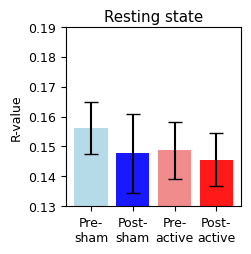

In [35]:
pre_sham = funcs.remove_outliers(np.array(presham), low_k=5, high_k=0.1, verbose=True)
post_sham = funcs.remove_outliers(np.array(postsham), low_k=5, high_k=3, verbose=True)
pre_active = funcs.remove_outliers(np.array(preactive), low_k=0.5, high_k=5, verbose=True)
post_active = funcs.remove_outliers(np.array(postactive), low_k=5, high_k=5, verbose=True)

means = [np.mean(pre_sham), np.mean(post_sham), np.mean(pre_active), np.mean(post_active)]

multiplier = 1   # 95% confidence interval
std_errors = [
    multiplier*np.std(pre_sham) / np.sqrt(len(pre_sham)), multiplier*np.std(post_sham) / np.sqrt(len(post_sham)),
    multiplier*np.std(pre_active) / np.sqrt(len(pre_active)), multiplier*np.std(post_active) / np.sqrt(len(post_active))
]

# Calculate t-tests
_, p_sham = stats.ttest_ind(pre_sham, post_sham)
_, p_real = stats.ttest_ind(pre_active, post_active)
_, p_pre = stats.ttest_ind(pre_sham, pre_active)
_, p_post = stats.ttest_ind(post_sham, post_active)

print(f"\nPre-sham vs. Post-sham: p = {p_sham}")
print(f"\nPre-active vs. Post-active: p = {p_real}")
print(f"\nPre-sham vs. Pre-active: p = {p_pre}")
print(f"\nPost-sham vs. Post-active: p = {p_post}")

# Bar chart
labels = ['Pre-\nsham', 'Post-\nsham', 'Pre-\nactive', 'Post-\nactive']
colors = ['lightblue', 'blue', 'lightcoral', 'red']

# Plotting
cm = 1/2.54  # centimeters in inches
fig, ax = plt.subplots(figsize=(6*cm, 6*cm))

# Plotting error bars
for i in range(4):
    ax.bar(labels[i], means[i], yerr=std_errors[i], color=colors[i], capsize=5, alpha=0.9)

plt.title('Resting state', pad=4)
# Add some additional formatting if desired
ax.set_ylabel('R-value')
# ax.set_title(case)
ax.set_ylim([0.13, 0.19])  # Adjust as needed
# ax.set_yticks([0.5, 1.0, 1.5])

matplotlib.rcParams.update({'font.size': 9})

# Adjust layout and margins
plt.tight_layout(pad=1.0)
# plt.title('Frontal cluster', pad=6)
fig.subplots_adjust(left=0.24, bottom=0.15, right=0.98, top=0.91)
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 3 excind', 'R_rest.eps')
plt.savefig(save_path, format='eps')
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 3 excind', 'R_rest.png')
plt.savefig(save_path, format='png', dpi=600)
plt.show()

In [36]:
# ANOVA
def make_anova_table(pre_sham, post_sham, pre_active, post_active, difficulty):
    df = pd.DataFrame(columns=['condition', 'task_time', 'difficulty', 'reaction_time'])
    # Create a new DataFrame for the new rows to be inserted
    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(pre_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(post_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': post_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(pre_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_active),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(post_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_active),  # Repeat 'endo valid' for the same length
        'reaction_time': post_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    return df


def fvalue_to_p(fvalue, df_num, df_denom):
    return 1 - stats.f.cdf(fvalue, df_num, df_denom)


anova_table = make_anova_table(pre_sham, post_sham, pre_active, post_active, 'rest')
# Assuming df is your DataFrame
# Ensure correct data types
# anova_table['reaction_time'] = anova_table['reaction_time'].astype('int')

anova_table['condition'] = anova_table['condition'].astype('category')
anova_table['task_time'] = anova_table['task_time'].astype('category')


# Fit the model
model = ols('reaction_time ~ C(condition) * C(task_time)', data=anova_table).fit()

# Perform ANOVAs
anova_results = anova_lm(model, typ=2)  # Using Type II Sum of Squares

# Calculate Eta Squared
anova_results['eta_sq'] = anova_results['sum_sq'] / sum(anova_results['sum_sq'])
anova_results['p'] = anova_results.apply(lambda row: fvalue_to_p(row['F'], row['df'], 26), axis=1)
anova_results['mod eta_sq'] = anova_results.apply(lambda row: row['eta_sq']*(532/26), axis=1)

anova_results

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_18820\4291551686.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)


,sum_sq,df,F,PR(>F),eta_sq,p,mod eta_sq
C(condition),0.000226,1.0,0.169104,0.683051,0.004075,0.684280,0.083391
C(task_time),0.000359,1.0,0.268838,0.606900,0.006479,0.608497,0.132573
C(condition):C(task_time),0.000073,1.0,0.054926,0.815870,0.001324,0.816539,0.027086
Residual,0.054736,41.0,NaN,NaN,0.988122,NaN,20.218489
